In [231]:
import matplotlib.pyplot as plt
import numpy as np
from datetime import datetime
from pathlib import Path
import ast
import matplotlib.dates as mdates
from datetime import timedelta
myFmt = mdates.DateFormatter('%H:%M:%S') 


In [232]:
def stat_reader(fname):
    f=open(fname)
    lines = f.readlines()
    tt=-1
    try:
        stat_dict = ast.literal_eval(lines[-2].strip()) 
        #with the journalctl line
        #2026-04-16 13:12:39.761784 Sync done -> model run start
        #2026-04-16 13:13:41.620737 model run end
        s_dt = datetime.strptime(lines[1].split(" Sync ")[0].split(".")[0],"%Y-%m-%d %H:%M:%S")
        e_dt = datetime.strptime(lines[2].split(" model ")[0].split(".")[0],"%Y-%m-%d %H:%M:%S")
        tt=(e_dt-s_dt).total_seconds()
    except Exception as e:
        stat_dict="failed_rank"

    
    

    # print(stat_dict)
    return stat_dict, tt

def tf_calc(w):
    y=0
    if w < 8:
        y = 0.157 - 0.004*27 + 0.075*w
    else:
        y = 0.667 - 0.008*27 + 0.023*w
    return y

def cdf_gen(arr, e=False):
    sorted_arr = sorted(arr)
    y=[]
    for x in range(len(sorted_arr)):
        counter = len(sorted_arr[x+1:]) if e else x+1
        y.append(counter/len(sorted_arr))
    return sorted_arr, y 


def filter_warmups(full_path, arrs, valid_cores=1, exp_len=11):
    # print(arrs)
    c=0
    msg=''
    marked = []
    for ind, _ in enumerate(arrs):
        arrs[ind]=[i for i in arrs[ind] if i > 0]
        # arrs[ind]=[i for i in arrs[ind] if i < min(arrs[ind])*2.5]
        if c < valid_cores:
            # assert len(arrs[ind]) == exp_len, f"{full_path} doesn't have valid runs?"
            if len(arrs[ind]) != exp_len:
                msg = f"{full_path} doesn't have valid runs?"
                marked.append(ind)

            c+=1
    correction = max([sum(arrs[ind]) for ind in range(len(arrs)) if ind not in marked])/1000
    return (arrs, correction, msg)


def throttle_measure(fname):
    f=open(fname)
    counter=0
    lines = f.readlines()
    for i in lines:
        if "Under" in i:
            counter+=1
    return counter




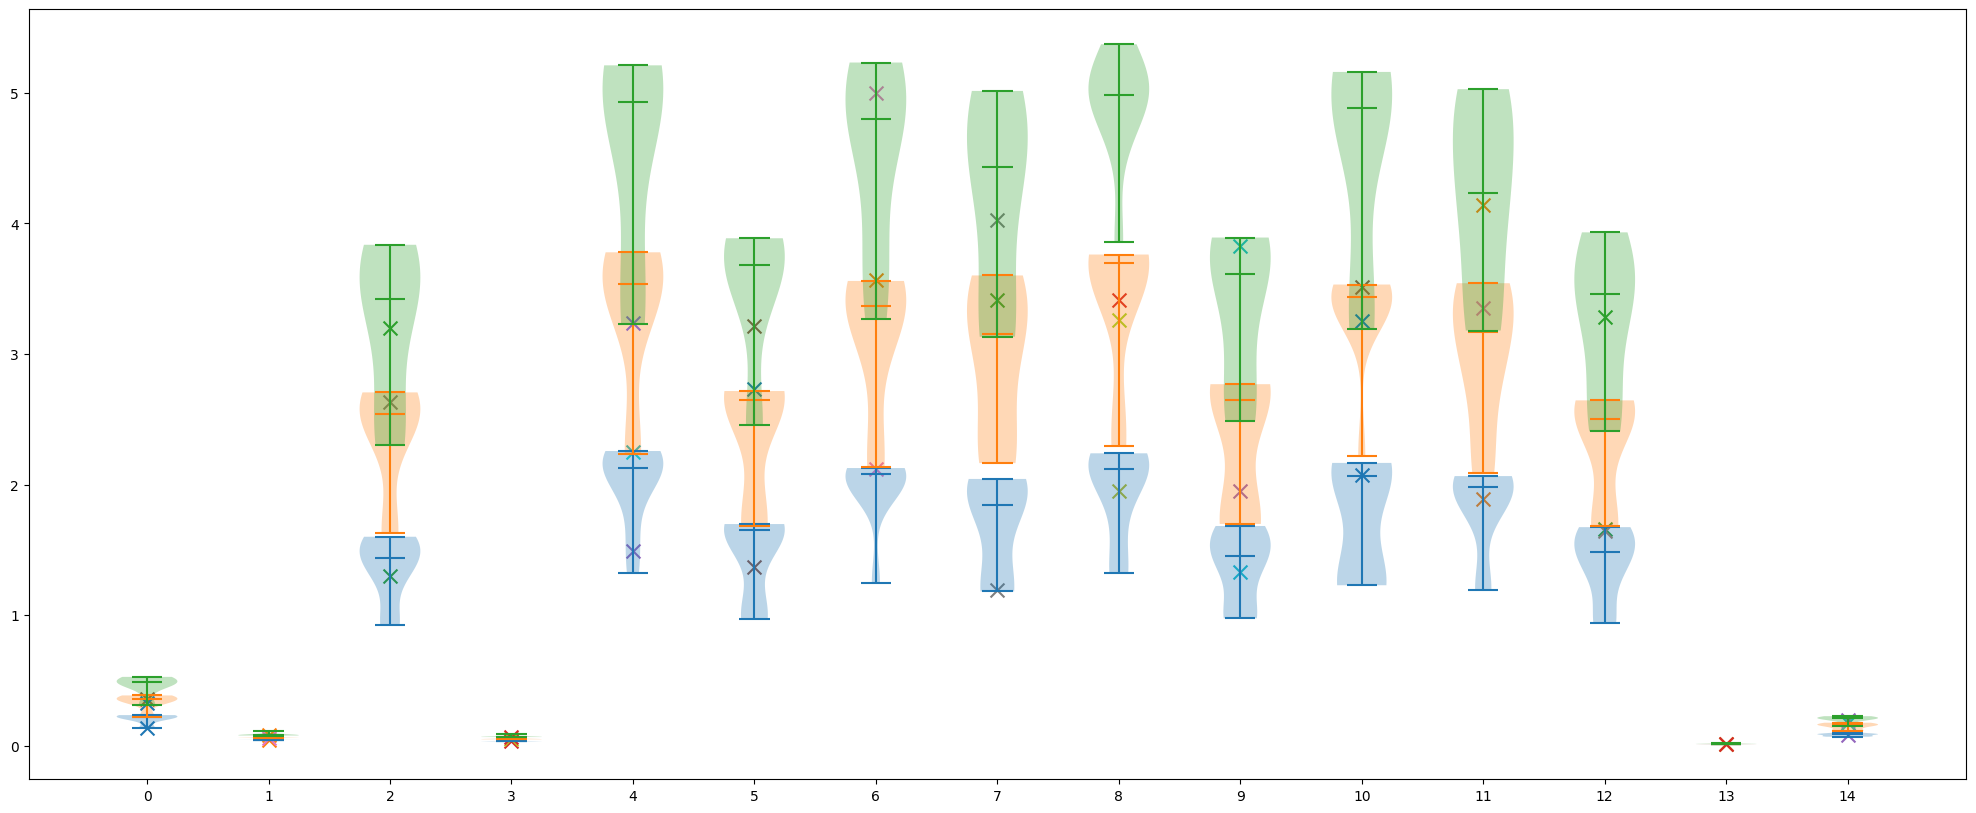

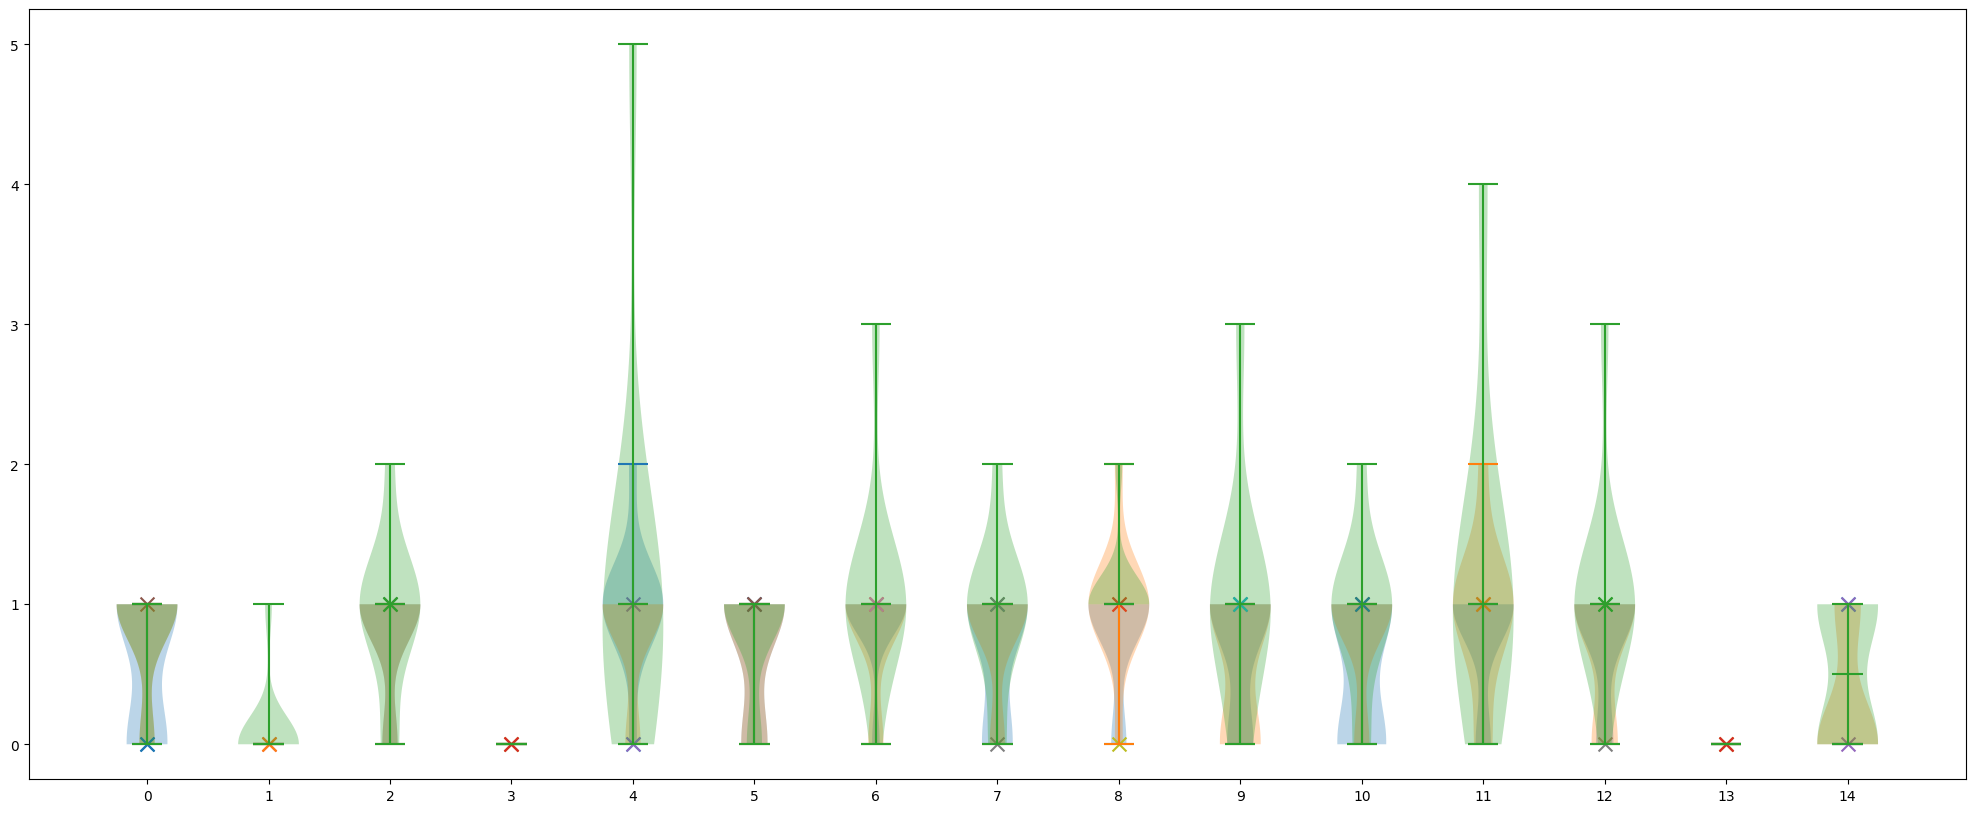

In [225]:
#1 core analysis of single_group_vit
# /Users/animeshnd/model_splitting/logs/single_group_heat/bramble-4-5/vit_modules/1_concurrency_level/1/3_1/speed_chronosbramble-4-5-9_2.log
cons = [1,10]
model="vit"
split_type="modules"
# cores=[1,2,3,4]
# cores=[1,2,3,4]
# cores=[1,2]
cores=[1,2, 3]
pdu_tag="bramble-4-1"
# pdu_tag="bramble-2-1"
prefix = "/Users/animeshnd/model_splitting/logs/single_group_heat/"
# worlds = [5]#,10]
worlds = [15]
comp_times={core:{con:{k:{r:[] for r in range(k)} for k in worlds} for con in cons} for core in cores}
throttle_times={core:{con:{k:{r:[] for r in range(k)} for k in worlds} for con in cons} for core in cores}
for con in cons:
    for world in worlds:
        for core in cores:
            for r in range(world):
                for dev in range(1,42):
                    full_path = f"{prefix}/{pdu_tag}/{model}_{split_type}/{con}_concurrency_level/1/{world}_{core}/speed_chronos{pdu_tag}-{dev}_{r}.log"
                    if Path.is_file(Path(full_path)):
                        m, tt = stat_reader(full_path)
                        if "fail" in m:
                            print(full_path)
                            continue
                        warmups = m["warmup"][0]
                        #warmup is 4 cores, so 4 arrays, each with len == number of iters + 1 (1==warmup iter)
                        #if we used all 4 cores -> each array should be these lens -> if an array has 0s or -ve values -> bad array!
                        # try:
                        try:
                            warmups, corr, msg = filter_warmups(full_path, warmups, valid_cores=core, exp_len=11)
                        
                            if len(msg)>0:
                                print(msg)
                                continue
                                # m["comp_times"][0] = corr
                        except Exception as e:
                        #     # m["comp_times"][0]
                            # print(full_path)
                            continue
                            # pass
                        j_full_path= f"{prefix}/{pdu_tag}/{model}_{split_type}/{con}_concurrency_level/1/{world}_{core}/speed_journal{pdu_tag}-{dev}_{r}.log"
                        if Path.is_file(Path(j_full_path)):
                            throttle_count = throttle_measure(j_full_path)
                        else:
                            throttle_count=0
                        if tt!=0:
                            # throttle_times[core][con][world][r].append(throttle_count/tt)
                            throttle_times[core][con][world][r].append(throttle_count)
                        else:
                            throttle_times[core][con][world][r].append(0)

                        comp_times[core][con][world][r].append(m["comp_times"][0]/10)

# colors=["blue", "orange", "green", "red", "purple", "brown", "pink", "grey"]
axs_map={}
for core in cores:
    for k in comp_times[core][1]:
        if k not in axs_map:
            fig, axs = plt.subplots(figsize=(25,10))
            axs_map[k]=axs
        axs=axs_map[k]
        for r in comp_times[core][1][k]:
            # if r in [1,13]:
            #     continue
            # print(k ,r)
            # print(comp_times[1][k][r])
            axs.scatter([r]*len(comp_times[core][1][k][r]), comp_times[core][1][k][r], marker="x", s=100)
        
        # axs.violin()
        # print(comp_times[k][r])
        # x,y = cdf_gen([round(i,3) for i in comp_times[k][r]])
        # axs.plot(x,y, label=f"rank_{r}")

    for k in comp_times[core][10]:
        axs=axs_map[k]
        # for r in comp_times[10][k]:
            # print(comp_times[10][k])
        # if core==1:
        #     dist = [[i*2 for i in v] for v_ind, v in enumerate(comp_times[core][10][k].values())]
        # else:
        dist = [[i for i in v] for v_ind, v in enumerate(comp_times[core][10][k].values())]

        dist = [[0] if len(d)==0 else d for d in dist] 
        # print(dist)
        axs.violinplot(dist, positions=np.arange(0,k, 1), showmedians=True)
        axs.set_xticks(np.arange(0,k, 1))



axs_map={}
for core in cores:
    for k in throttle_times[core][1]:
        if k not in axs_map:
            fig, axs = plt.subplots(figsize=(25,10))
            axs_map[k]=axs
        axs=axs_map[k]
        for r in throttle_times[core][1][k]:
            # if r in [1,13]:
            #     continue
            # print(k ,r)
            # print(comp_times[1][k][r])
            axs.scatter([r]*len(throttle_times[core][1][k][r]), throttle_times[core][1][k][r], marker="x", s=100)
        
        # axs.violin()
        # print(comp_times[k][r])
        # x,y = cdf_gen([round(i,3) for i in comp_times[k][r]])
        # axs.plot(x,y, label=f"rank_{r}")

    for k in throttle_times[core][10]:
        axs=axs_map[k]
        # for r in comp_times[10][k]:
            # print(comp_times[10][k])
        # if core==1:
        #     dist = [[i*2 for i in v] for v_ind, v in enumerate(comp_times[core][10][k].values())]
        # else:
        dist = [[i for i in v] for v_ind, v in enumerate(throttle_times[core][10][k].values())]

        dist = [[0] if len(d)==0 else d for d in dist] 
        # print(dist)
        axs.violinplot(dist, positions=np.arange(0,k, 1), showmedians=True)
        axs.set_xticks(np.arange(0,k, 1))
# for k in comp_times[4][10]:
#     axs=axs_map[k]
#     dist = [v for v in comp_times[4][10][k].values()]
#     # print(dist)
#     dist = [[0] if len(d)==0 else d for d in dist] 
#     # for r in comp_times[10][k]:
#         # print(comp_times[10][k])
#     axs.violinplot(dist, positions=np.arange(0,k, 1), showmedians=True)
#     # axs.set_xticks(np.arange(0,k, 1))

# for k in comp_times[4][1]:
#     axs=axs_map[k]
#     for r in comp_times[4][1][k]:
#         axs.scatter([r]*len(comp_times[4][1][k][r]), comp_times[4][1][k][r], marker="x", s=100)
    # for r in comp_times[10][k]:
        # print(comp_times[10][k])
    # axs.violinplot([v for v in comp_times[4][10][k].values()], positions=np.arange(0,k, 1), showmedians=True)
    # axs.set_xticks(np.arange(0,k, 1))


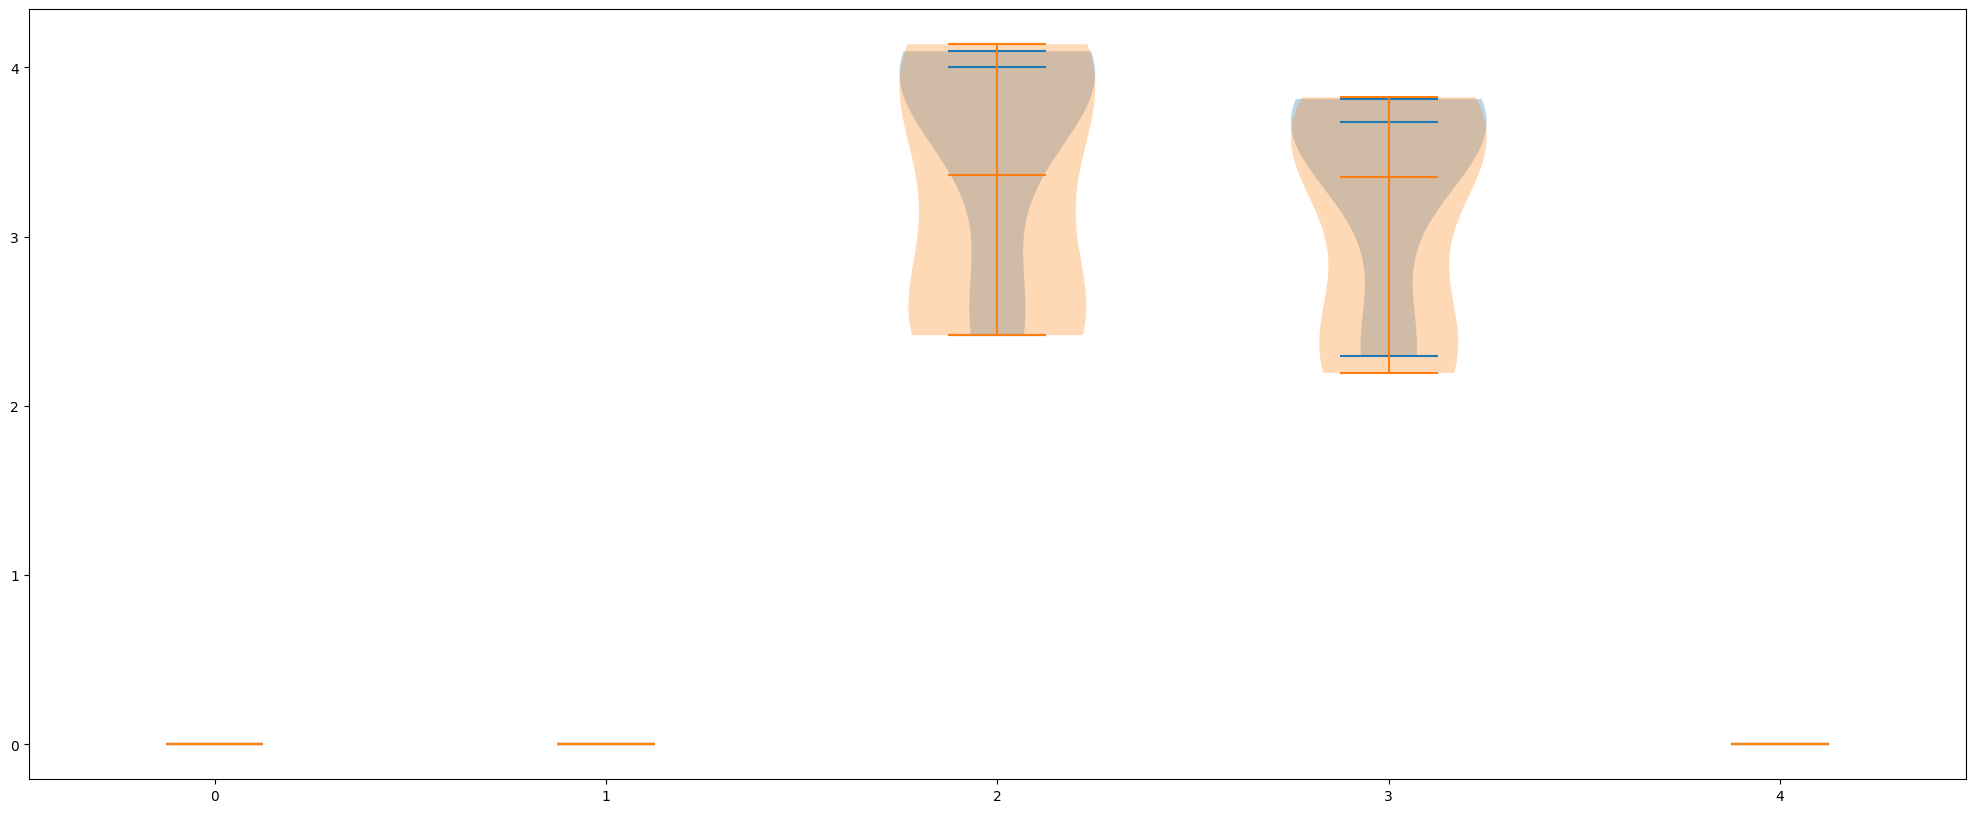

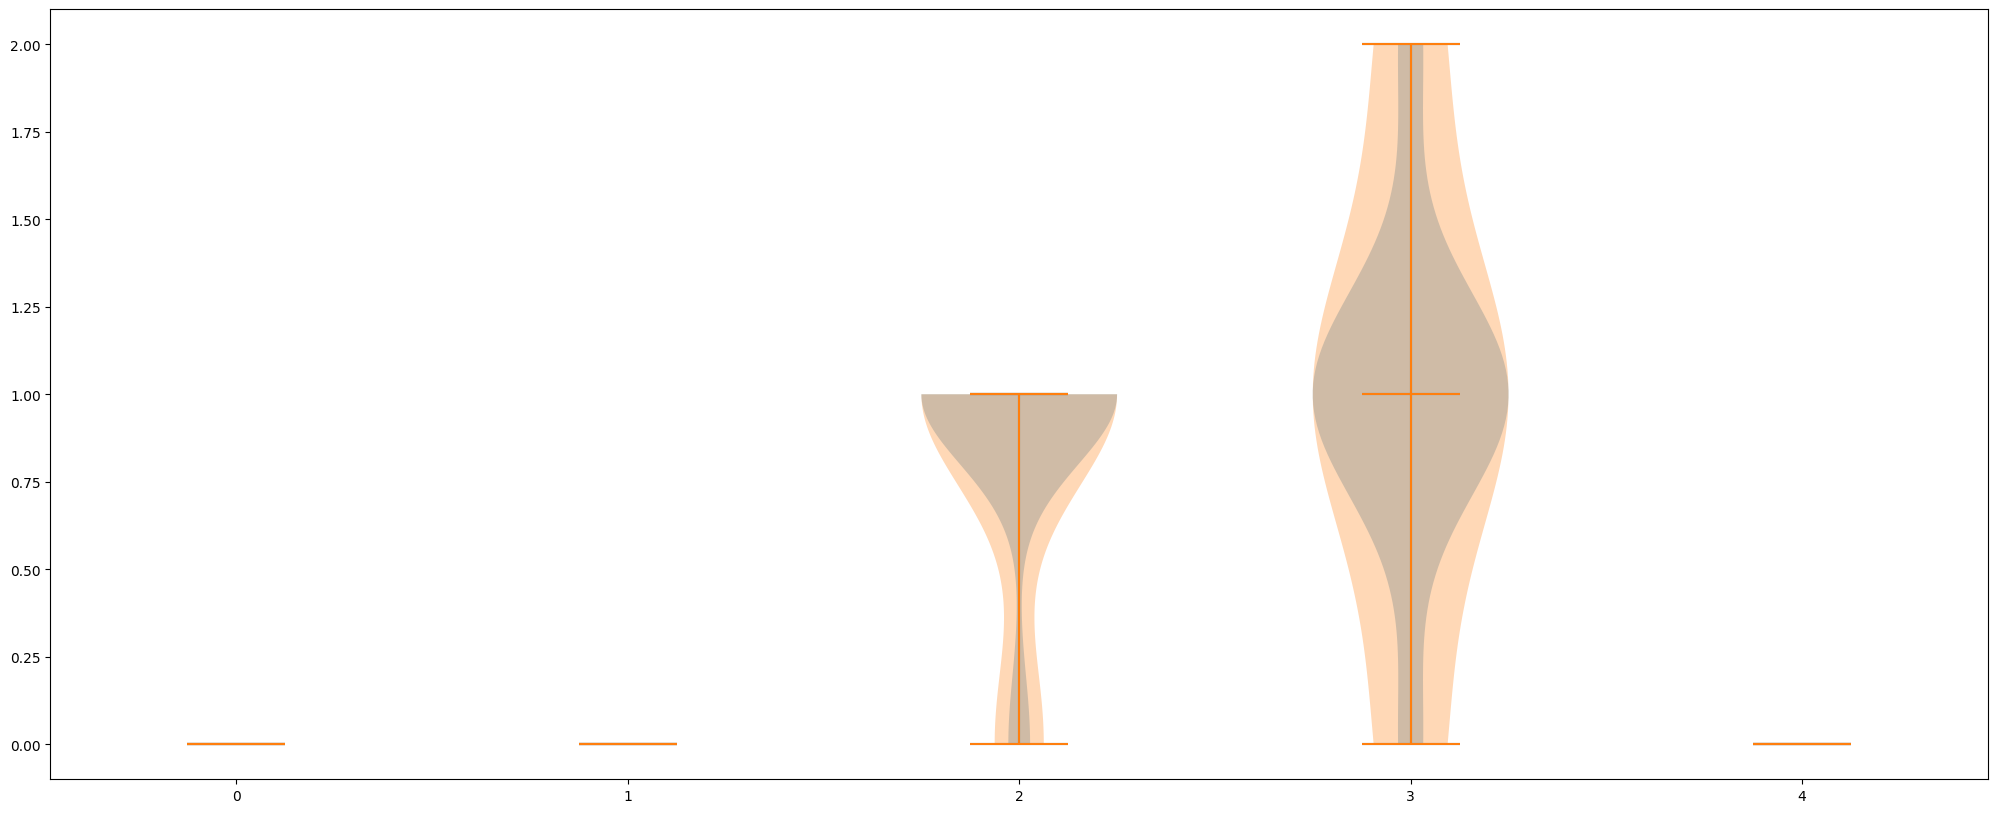

In [227]:
#1 core analysis of single_group_vit
# /Users/animeshnd/model_splitting/logs/single_group_heat/bramble-4-5/vit_modules/1_concurrency_level/1/3_1/speed_chronosbramble-4-5-9_2.log
cons = [1,10]
model="vit"
split_type="modules"
# cores=[1,2,3,4]
# cores=[1,2,3,4]
# cores=[1,2]
cores=[0,1]
# pdu_tag="bramble-4-1"
pdu_tag="bramble-2-1"
prefix = "/Users/animeshnd/model_splitting/logs/single_group_heat_con/"
worlds = [5]#,10]
# worlds = [15]
comp_times={core:{con:{k:{r:[] for r in range(k)} for k in worlds} for con in cons} for core in cores}
throttle_times={core:{con:{k:{r:[] for r in range(k)} for k in worlds} for con in cons} for core in cores}
for con in cons:
    for world in worlds:
        for core in cores:
            for r in range(world):
                for dev in range(1,42):
                    full_path = f"{prefix}/{pdu_tag}/{model}_{split_type}/{con}_concurrency_level/1/{world}_{core}/speed_chronos{pdu_tag}-{dev}_{r}.log"
                    if Path.is_file(Path(full_path)):
                        m, tt = stat_reader(full_path)
                        if "fail" in m:
                            print(full_path)
                            continue
                        warmups = m["warmup"][0]
                        #warmup is 4 cores, so 4 arrays, each with len == number of iters + 1 (1==warmup iter)
                        #if we used all 4 cores -> each array should be these lens -> if an array has 0s or -ve values -> bad array!
                        # try:
                        try:
                            warmups, corr, msg = filter_warmups(full_path, warmups, valid_cores=core, exp_len=11)
                        
                            if len(msg)>0:
                                print(msg)
                                continue
                                # m["comp_times"][0] = corr
                        except Exception as e:
                        #     # m["comp_times"][0]
                            # print(full_path)
                            continue
                            # pass
                        j_full_path= f"{prefix}/{pdu_tag}/{model}_{split_type}/{con}_concurrency_level/1/{world}_{core}/speed_journal{pdu_tag}-{dev}_{r}.log"
                        if Path.is_file(Path(j_full_path)):
                            throttle_count = throttle_measure(j_full_path)
                        else:
                            throttle_count=0
                        if tt!=0:
                            # throttle_times[core][con][world][r].append(throttle_count/tt)
                            throttle_times[core][con][world][r].append(throttle_count)
                        else:
                            throttle_times[core][con][world][r].append(0)

                        comp_times[core][con][world][r].append(m["comp_times"][0]/10)

# colors=["blue", "orange", "green", "red", "purple", "brown", "pink", "grey"]
axs_map={}
for core in cores:
    for k in comp_times[core][1]:
        if k not in axs_map:
            fig, axs = plt.subplots(figsize=(25,10))
            axs_map[k]=axs
        axs=axs_map[k]
        for r in comp_times[core][1][k]:
            # if r in [1,13]:
            #     continue
            # print(k ,r)
            # print(comp_times[1][k][r])
            axs.scatter([r]*len(comp_times[core][1][k][r]), comp_times[core][1][k][r], marker="x", s=100)
        
        # axs.violin()
        # print(comp_times[k][r])
        # x,y = cdf_gen([round(i,3) for i in comp_times[k][r]])
        # axs.plot(x,y, label=f"rank_{r}")

    for k in comp_times[core][10]:
        axs=axs_map[k]
        # for r in comp_times[10][k]:
            # print(comp_times[10][k])
        # if core==1:
        #     dist = [[i*2 for i in v] for v_ind, v in enumerate(comp_times[core][10][k].values())]
        # else:
        dist = [[i for i in v] for v_ind, v in enumerate(comp_times[core][10][k].values())]

        dist = [[0] if len(d)==0 else d for d in dist] 
        # print(dist)
        axs.violinplot(dist, positions=np.arange(0,k, 1), showmedians=True)
        axs.set_xticks(np.arange(0,k, 1))



axs_map={}
for core in cores:
    for k in throttle_times[core][1]:
        if k not in axs_map:
            fig, axs = plt.subplots(figsize=(25,10))
            axs_map[k]=axs
        axs=axs_map[k]
        for r in throttle_times[core][1][k]:
            # if r in [1,13]:
            #     continue
            # print(k ,r)
            # print(comp_times[1][k][r])
            axs.scatter([r]*len(throttle_times[core][1][k][r]), throttle_times[core][1][k][r], marker="x", s=100)
        
        # axs.violin()
        # print(comp_times[k][r])
        # x,y = cdf_gen([round(i,3) for i in comp_times[k][r]])
        # axs.plot(x,y, label=f"rank_{r}")

    for k in throttle_times[core][10]:
        axs=axs_map[k]
        # for r in comp_times[10][k]:
            # print(comp_times[10][k])
        # if core==1:
        #     dist = [[i*2 for i in v] for v_ind, v in enumerate(comp_times[core][10][k].values())]
        # else:
        dist = [[i for i in v] for v_ind, v in enumerate(throttle_times[core][10][k].values())]

        dist = [[0] if len(d)==0 else d for d in dist] 
        # print(dist)
        axs.violinplot(dist, positions=np.arange(0,k, 1), showmedians=True)
        axs.set_xticks(np.arange(0,k, 1))
# for k in comp_times[4][10]:
#     axs=axs_map[k]
#     dist = [v for v in comp_times[4][10][k].values()]
#     # print(dist)
#     dist = [[0] if len(d)==0 else d for d in dist] 
#     # for r in comp_times[10][k]:
#         # print(comp_times[10][k])
#     axs.violinplot(dist, positions=np.arange(0,k, 1), showmedians=True)
#     # axs.set_xticks(np.arange(0,k, 1))

# for k in comp_times[4][1]:
#     axs=axs_map[k]
#     for r in comp_times[4][1][k]:
#         axs.scatter([r]*len(comp_times[4][1][k][r]), comp_times[4][1][k][r], marker="x", s=100)
    # for r in comp_times[10][k]:
        # print(comp_times[10][k])
    # axs.violinplot([v for v in comp_times[4][10][k].values()], positions=np.arange(0,k, 1), showmedians=True)
    # axs.set_xticks(np.arange(0,k, 1))


/Users/animeshnd/model_splitting/logs/single_group_heat_con//bramble-4-1/resnet18_modules/10_concurrency_level/1/2_0/speed_chronosbramble-4-1-6_0.log
/Users/animeshnd/model_splitting/logs/single_group_heat_con//bramble-4-1/resnet18_modules/10_concurrency_level/1/2_0/speed_chronosbramble-4-1-11_0.log
/Users/animeshnd/model_splitting/logs/single_group_heat_con//bramble-4-1/resnet18_modules/10_concurrency_level/1/2_0/speed_chronosbramble-4-1-13_0.log
/Users/animeshnd/model_splitting/logs/single_group_heat_con//bramble-4-1/resnet18_modules/10_concurrency_level/1/2_0/speed_chronosbramble-4-1-24_0.log
/Users/animeshnd/model_splitting/logs/single_group_heat_con//bramble-4-1/resnet18_modules/10_concurrency_level/1/2_0/speed_chronosbramble-4-1-26_0.log
/Users/animeshnd/model_splitting/logs/single_group_heat_con//bramble-4-1/resnet18_modules/10_concurrency_level/1/2_0/speed_chronosbramble-4-1-29_0.log
/Users/animeshnd/model_splitting/logs/single_group_heat_con//bramble-4-1/resnet18_modules/10_co

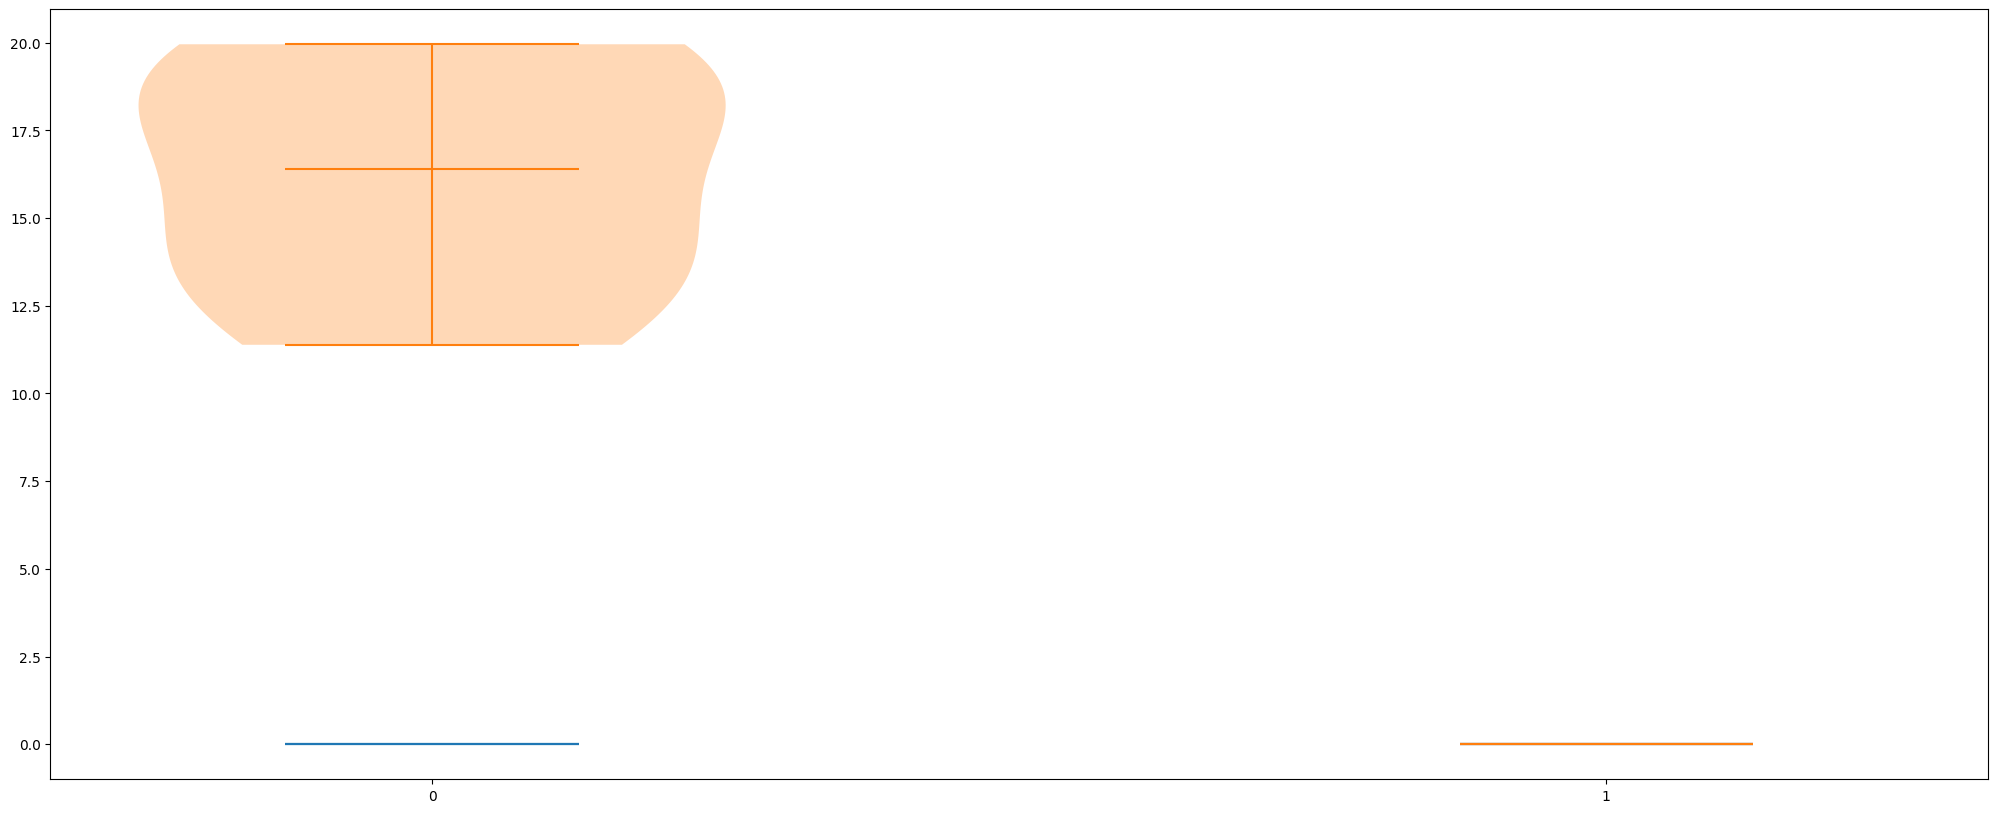

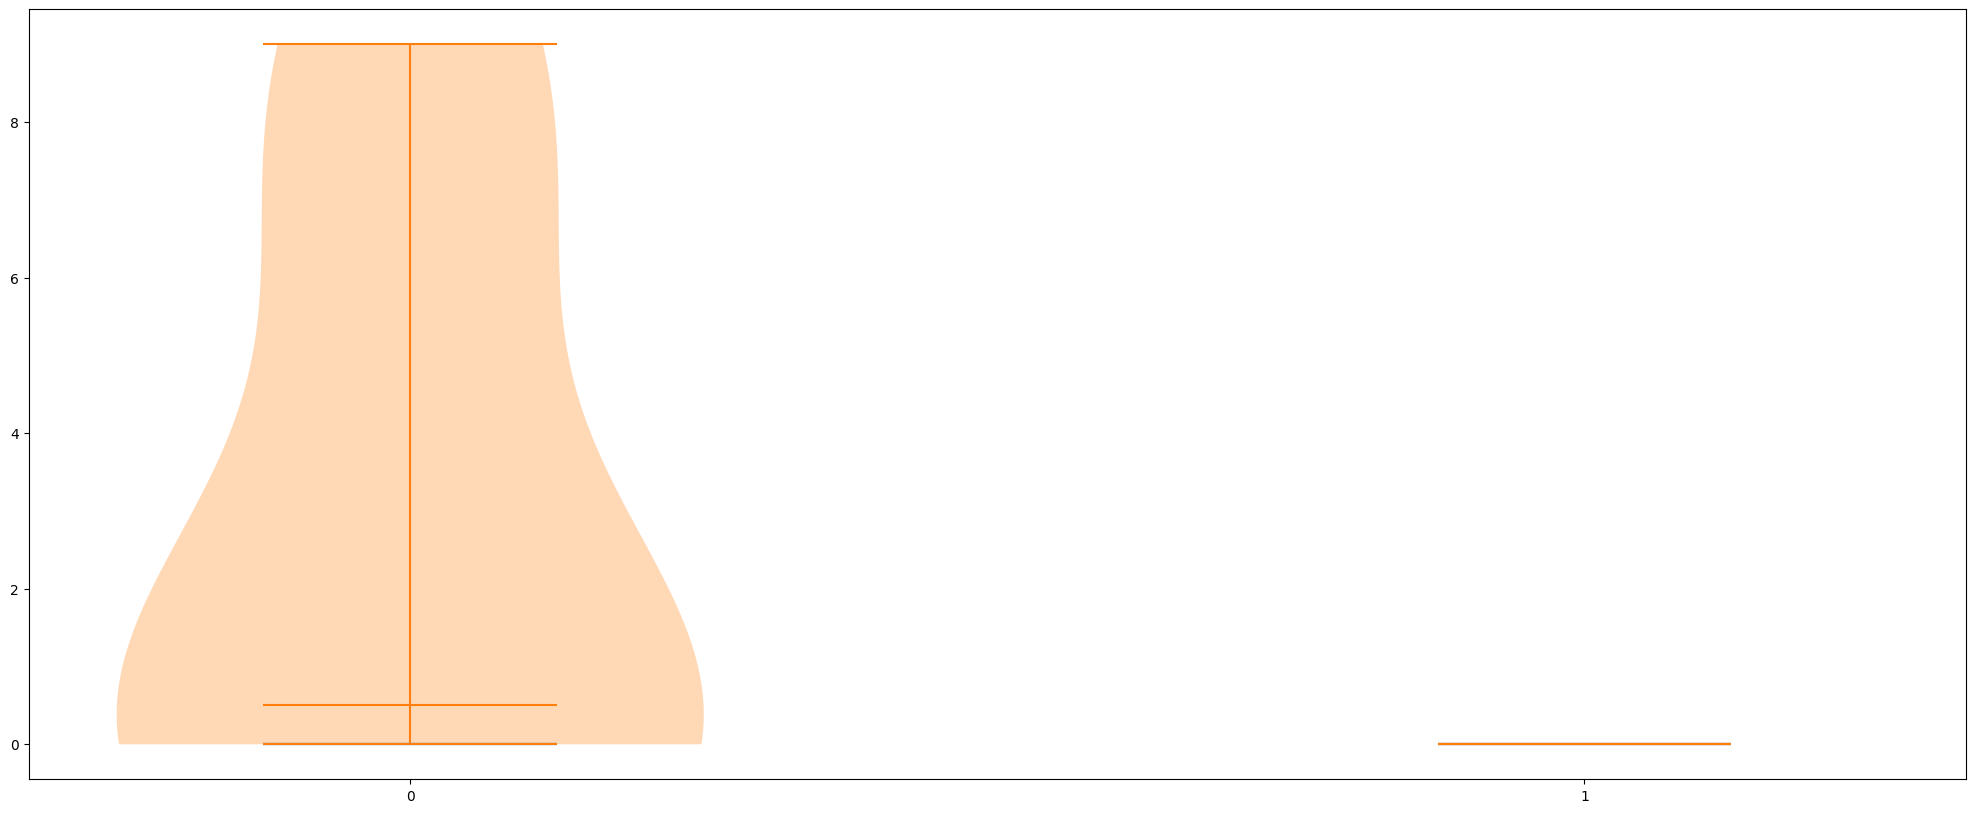

In [235]:
#1 core analysis of single_group_vit
# /Users/animeshnd/model_splitting/logs/single_group_heat/bramble-4-5/vit_modules/1_concurrency_level/1/3_1/speed_chronosbramble-4-5-9_2.log
cons = [1,10]
model="resnet18"
split_type="modules"
# cores=[1,2,3,4]
# cores=[1,2,3,4]
# cores=[1,2]
cores=[0,1]
pdu_tag="bramble-4-1"
# pdu_tag="bramble-2-1"
prefix = "/Users/animeshnd/model_splitting/logs/single_group_heat_con/"
worlds = [2]#,10]
# worlds = [15]
comp_times={core:{con:{k:{r:[] for r in range(k)} for k in worlds} for con in cons} for core in cores}
throttle_times={core:{con:{k:{r:[] for r in range(k)} for k in worlds} for con in cons} for core in cores}
for con in cons:
    for world in worlds:
        for core in cores:
            for r in range(world):
                for dev in range(1,42):
                    full_path = f"{prefix}/{pdu_tag}/{model}_{split_type}/{con}_concurrency_level/1/{world}_{core}/speed_chronos{pdu_tag}-{dev}_{r}.log"
                    if Path.is_file(Path(full_path)):
                        m, tt = stat_reader(full_path)
                        if "fail" in m:
                            print(full_path)
                            continue
                        warmups = m["warmup"][0]
                        #warmup is 4 cores, so 4 arrays, each with len == number of iters + 1 (1==warmup iter)
                        #if we used all 4 cores -> each array should be these lens -> if an array has 0s or -ve values -> bad array!
                        # try:
                        try:
                            warmups, corr, msg = filter_warmups(full_path, warmups, valid_cores=core, exp_len=11)
                        
                            if len(msg)>0:
                                print(msg)
                                continue
                                # m["comp_times"][0] = corr
                        except Exception as e:
                        #     # m["comp_times"][0]
                            # print(full_path)
                            continue
                            # pass
                        j_full_path= f"{prefix}/{pdu_tag}/{model}_{split_type}/{con}_concurrency_level/1/{world}_{core}/speed_journal{pdu_tag}-{dev}_{r}.log"
                        if Path.is_file(Path(j_full_path)):
                            throttle_count = throttle_measure(j_full_path)
                        else:
                            throttle_count=0
                        if tt!=0:
                            # throttle_times[core][con][world][r].append(throttle_count/tt)
                            throttle_times[core][con][world][r].append(throttle_count)
                        else:
                            throttle_times[core][con][world][r].append(0)

                        comp_times[core][con][world][r].append(m["comp_times"][0]/10)

# colors=["blue", "orange", "green", "red", "purple", "brown", "pink", "grey"]
axs_map={}
for core in cores:
    for k in comp_times[core][1]:
        if k not in axs_map:
            fig, axs = plt.subplots(figsize=(25,10))
            axs_map[k]=axs
        axs=axs_map[k]
        for r in comp_times[core][1][k]:
            # if r in [1,13]:
            #     continue
            # print(k ,r)
            # print(comp_times[1][k][r])
            axs.scatter([r]*len(comp_times[core][1][k][r]), comp_times[core][1][k][r], marker="x", s=100)
        
        # axs.violin()
        # print(comp_times[k][r])
        # x,y = cdf_gen([round(i,3) for i in comp_times[k][r]])
        # axs.plot(x,y, label=f"rank_{r}")

    for k in comp_times[core][10]:
        axs=axs_map[k]
        # for r in comp_times[10][k]:
            # print(comp_times[10][k])
        # if core==1:
        #     dist = [[i*2 for i in v] for v_ind, v in enumerate(comp_times[core][10][k].values())]
        # else:
        dist = [[i for i in v] for v_ind, v in enumerate(comp_times[core][10][k].values())]

        dist = [[0] if len(d)==0 else d for d in dist] 
        # print(dist)
        axs.violinplot(dist, positions=np.arange(0,k, 1), showmedians=True)
        axs.set_xticks(np.arange(0,k, 1))



axs_map={}
for core in cores:
    for k in throttle_times[core][1]:
        if k not in axs_map:
            fig, axs = plt.subplots(figsize=(25,10))
            axs_map[k]=axs
        axs=axs_map[k]
        for r in throttle_times[core][1][k]:
            # if r in [1,13]:
            #     continue
            # print(k ,r)
            # print(comp_times[1][k][r])
            axs.scatter([r]*len(throttle_times[core][1][k][r]), throttle_times[core][1][k][r], marker="x", s=100)
        
        # axs.violin()
        # print(comp_times[k][r])
        # x,y = cdf_gen([round(i,3) for i in comp_times[k][r]])
        # axs.plot(x,y, label=f"rank_{r}")

    for k in throttle_times[core][10]:
        axs=axs_map[k]
        # for r in comp_times[10][k]:
            # print(comp_times[10][k])
        # if core==1:
        #     dist = [[i*2 for i in v] for v_ind, v in enumerate(comp_times[core][10][k].values())]
        # else:
        dist = [[i for i in v] for v_ind, v in enumerate(throttle_times[core][10][k].values())]

        dist = [[0] if len(d)==0 else d for d in dist] 
        # print(dist)
        axs.violinplot(dist, positions=np.arange(0,k, 1), showmedians=True)
        axs.set_xticks(np.arange(0,k, 1))
# for k in comp_times[4][10]:
#     axs=axs_map[k]
#     dist = [v for v in comp_times[4][10][k].values()]
#     # print(dist)
#     dist = [[0] if len(d)==0 else d for d in dist] 
#     # for r in comp_times[10][k]:
#         # print(comp_times[10][k])
#     axs.violinplot(dist, positions=np.arange(0,k, 1), showmedians=True)
#     # axs.set_xticks(np.arange(0,k, 1))

# for k in comp_times[4][1]:
#     axs=axs_map[k]
#     for r in comp_times[4][1][k]:
#         axs.scatter([r]*len(comp_times[4][1][k][r]), comp_times[4][1][k][r], marker="x", s=100)
    # for r in comp_times[10][k]:
        # print(comp_times[10][k])
    # axs.violinplot([v for v in comp_times[4][10][k].values()], positions=np.arange(0,k, 1), showmedians=True)
    # axs.set_xticks(np.arange(0,k, 1))


In [223]:
test={0: [(1, 3, 224, 224), 'torch.float32'], 1: [(1, 768, 14, 14), 'torch.float32'], 2: [(1, 197, 768), 'torch.float32'], 3: [(302592,), 'torch.float32', 2, [[1, 197, 768], [1, 197, 768]]], 4: [(1, 197, 768), 'torch.float32'], 5: [(302592,), 'torch.float32', 2, [[1, 197, 768], [1, 197, 768]]], 6: [(302592,), 'torch.float32', 2, [[1, 197, 768], [1, 197, 768]]], 7: [(756480,), 'torch.float32', 2, [[1, 197, 3072], [1, 197, 768]]], 8: [(302592,), 'torch.float32', 2, [[1, 197, 768], [1, 197, 768]]], 9: [(302592,), 'torch.float32', 2, [[1, 197, 768], [1, 197, 768]]], 10: [(302592,), 'torch.float32', 2, [[1, 197, 768], [1, 197, 768]]], 11: [(756480,), 'torch.float32', 2, [[1, 197, 3072], [1, 197, 768]]], 12: [(302592,), 'torch.float32', 2, [[1, 197, 768], [1, 197, 768]]], 13: [(1, 197, 768), 'torch.float32'], 14: [(1, 197, 768), 'torch.float32'], 15: [(1, 1000), 'torch.float32']}
# test={0: [(1, 3, 224, 224), 'torch.float32'], 1: [(302592,), 'torch.float32', 2, [[1, 197, 768], [1, 197, 768]]], 2: [(756480,), 'torch.float32', 2, [[1, 197, 3072], [1, 197, 768]]], 3: [(302592,), 'torch.float32', 2, [[1, 197, 768], [1, 197, 768]]], 4: [(756480,), 'torch.float32', 2, [[1, 197, 3072], [1, 197, 768]]], 5: [(1, 1000), 'torch.float32']}
total_time=0
for r in test:
    msg_size = 0
    accum=1
    for a in test[r][0]:
        accum*=a
    entry_size = 32 #if '32' in test[r][1] else 64
    bits = entry_size*accum
    msg_size = (bits/8)
    total_time+=bits/10**9
    # print(r, msg_size, bits/10**9)

print(total_time) #0.072629504s vs 0.145227 lmao



0.14522700800000002
